In [1]:
"""
EDA_Analysis.ipynb

Exploratory Data Analysis for Bluestock Mutual Fund Analytics.
Covers NAV trends, AUM growth, SIP inflows, investor demographics,
geographic distribution, folio growth, return correlations, and
sector allocation across the 40-fund universe.
"""

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "data/raw"
CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

fund_master = pd.read_csv(f"{DATA_DIR}/01_fund_master.csv")
nav_history = pd.read_csv(f"{DATA_DIR}/02_nav_history.csv", parse_dates=["date"])
aum_by_house = pd.read_csv(f"{DATA_DIR}/03_aum_by_fund_house.csv", parse_dates=["date"])
sip_inflows = pd.read_csv(f"{DATA_DIR}/04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv(f"{DATA_DIR}/05_category_inflows.csv")
folio_count = pd.read_csv(f"{DATA_DIR}/06_industry_folio_count.csv")
transactions = pd.read_csv(f"{DATA_DIR}/08_investor_transactions.csv", parse_dates=["transaction_date"])
holdings = pd.read_csv(f"{DATA_DIR}/09_portfolio_holdings.csv")

print("All datasets loaded successfully")
print(f"Funds: {fund_master.shape[0]}, NAV records: {nav_history.shape[0]}, Transactions: {transactions.shape[0]}")

All datasets loaded successfully
Funds: 40, NAV records: 46000, Transactions: 32778


In [2]:
# Chart 1: Daily NAV for all 40 schemes, 2022-2026, with bull run / correction highlights
nav_wide = nav_history.pivot(index="date", columns="amfi_code", values="nav")
nav_wide.columns = [fund_master.set_index("amfi_code").loc[c, "scheme_name"] for c in nav_wide.columns]

fig1 = go.Figure()
for col in nav_wide.columns:
    fig1.add_trace(go.Scatter(x=nav_wide.index, y=nav_wide[col], mode="lines", line=dict(width=1), name=col, showlegend=False))

# Highlight 2023 bull run
fig1.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0,
               annotation_text="2023 Bull Run", annotation_position="top left")

# Highlight 2024 correction
fig1.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.1, line_width=0,
               annotation_text="2024 Correction", annotation_position="top left")

fig1.update_layout(title="Daily NAV — All 40 Schemes (2022-2026)", xaxis_title="Date", yaxis_title="NAV", height=600)
fig1.write_image(f"{CHARTS_DIR}/01_nav_trend_all_schemes.png", width=1400, height=700)
fig1.show()

In [3]:
import sys
print(sys.executable)

c:\Users\vinodk\mutual-fund-analytics\venv\Scripts\python.exe


In [4]:
import subprocess
result = subprocess.run([sys.executable, "-m", "pip", "show", "kaleido"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Name: kaleido
Version: 1.4.0
Summary: Plotly graph export library
Home-page: https://github.com/plotly/kaleido
Author: 
Author-email: Andrew Pikul <ajpikul@gmail.com>, Neyberson Atencio <neyberatencio@gmail.com>
License: The MIT License (MIT)

Copyright (c) Plotly, Inc

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTI

In [5]:
import subprocess
result = subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "kaleido"], capture_output=True, text=True)
print(result.stdout[-1000:])
print(result.stderr[-1000:])



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



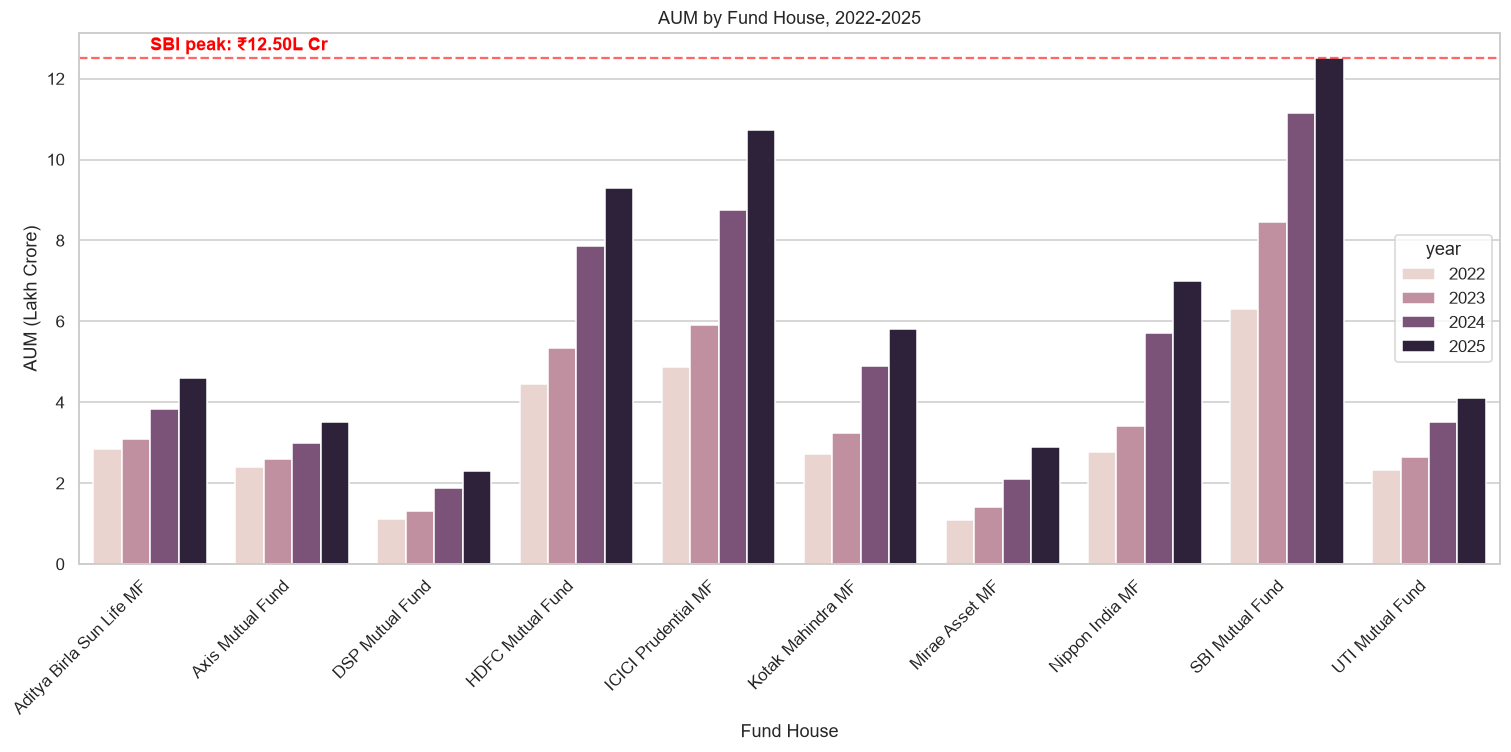

In [7]:
# Chart 2: Grouped bar chart - AUM by fund house, one bar group per year (2022-2025)
aum_yearly = aum_by_house.copy()
aum_yearly["year"] = aum_yearly["date"].dt.year
aum_yearly = aum_yearly[aum_yearly["year"] <= 2025]

# Take year-end snapshot per fund house per year
aum_yearly = aum_yearly.sort_values("date").groupby(["year", "fund_house"]).last().reset_index()

fig2, ax2 = plt.subplots(figsize=(14, 7))
sns.barplot(data=aum_yearly, x="fund_house", y="aum_lakh_crore", hue="year", ax=ax2)

# Highlight SBI's dominance
sbi_max = aum_yearly[aum_yearly["fund_house"] == "SBI Mutual Fund"]["aum_lakh_crore"].max()
ax2.axhline(sbi_max, color="red", linestyle="--", alpha=0.6)
ax2.text(0, sbi_max + 0.2, f"SBI peak: ₹{sbi_max:.2f}L Cr", color="red", fontweight="bold")

ax2.set_title("AUM by Fund House, 2022-2025")
ax2.set_xlabel("Fund House")
ax2.set_ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_aum_growth_by_house.png")
plt.show()

In [8]:
# Chart 3: Monthly SIP inflow trend, Jan 2022 - Dec 2025, with all-time-high annotation
sip_inflows_sorted = sip_inflows.sort_values("month")
peak_row = sip_inflows_sorted.loc[sip_inflows_sorted["sip_inflow_crore"].idxmax()]

fig3 = go.Figure()
fig3.add_trace(go.Scatter(
    x=sip_inflows_sorted["month"], y=sip_inflows_sorted["sip_inflow_crore"],
    mode="lines+markers", line=dict(color="royalblue", width=2), name="SIP Inflow"
))

fig3.add_annotation(
    x=peak_row["month"], y=peak_row["sip_inflow_crore"],
    text=f"All-time high: ₹{peak_row['sip_inflow_crore']:,} Cr ({peak_row['month']})",
    showarrow=True, arrowhead=2, ax=-60, ay=-40
)

fig3.update_layout(title="Monthly SIP Inflows (Jan 2022 - Dec 2025)", xaxis_title="Month", yaxis_title="SIP Inflow (₹ Crore)", height=500)
fig3.write_image(f"{CHARTS_DIR}/03_sip_inflow_trend.png", width=1400, height=600)
fig3.show()

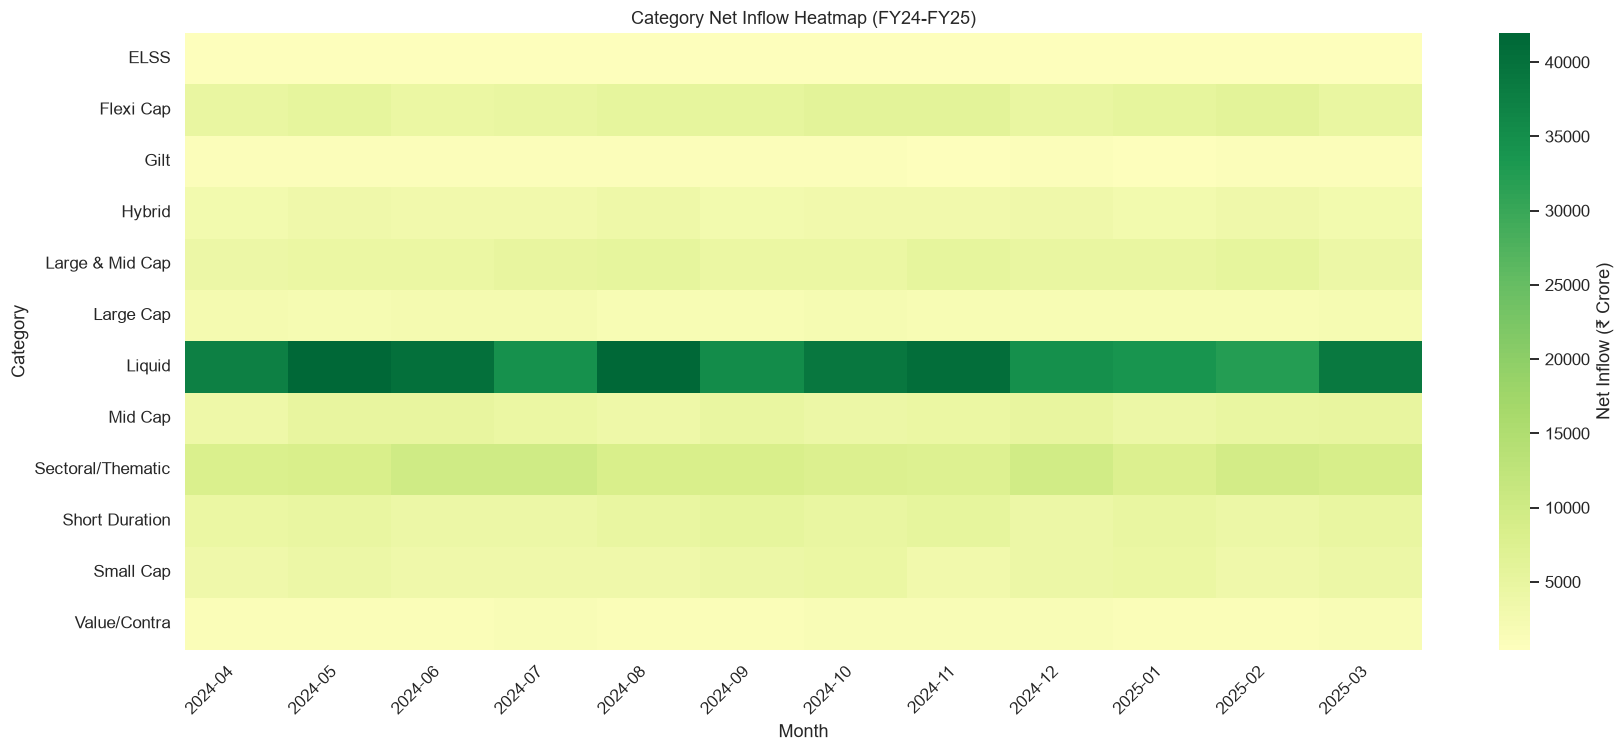

In [9]:
# Chart 4: Category inflow heatmap - months (X) vs categories (Y), color = net inflow
heatmap_data = category_inflows.pivot(index="category", columns="month", values="net_inflow_crore")

fig4, ax4 = plt.subplots(figsize=(16, 7))
sns.heatmap(heatmap_data, cmap="RdYlGn", center=0, annot=False, cbar_kws={"label": "Net Inflow (₹ Crore)"}, ax=ax4)
ax4.set_title("Category Net Inflow Heatmap (FY24-FY25)")
ax4.set_xlabel("Month")
ax4.set_ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_category_inflow_heatmap.png")
plt.show()

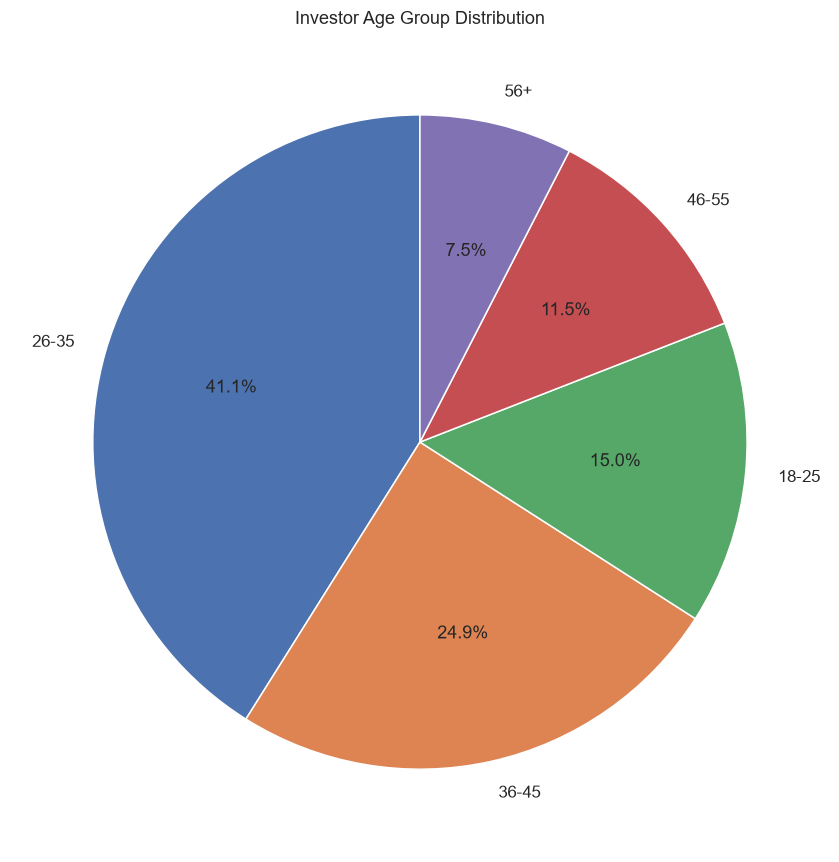

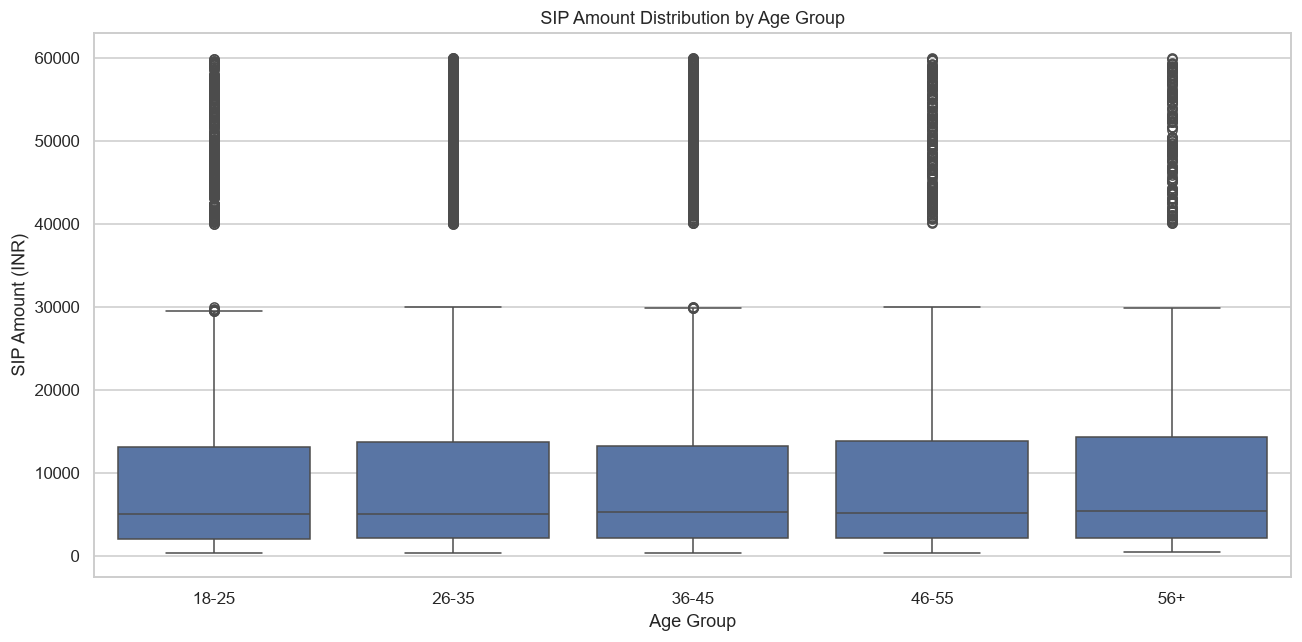

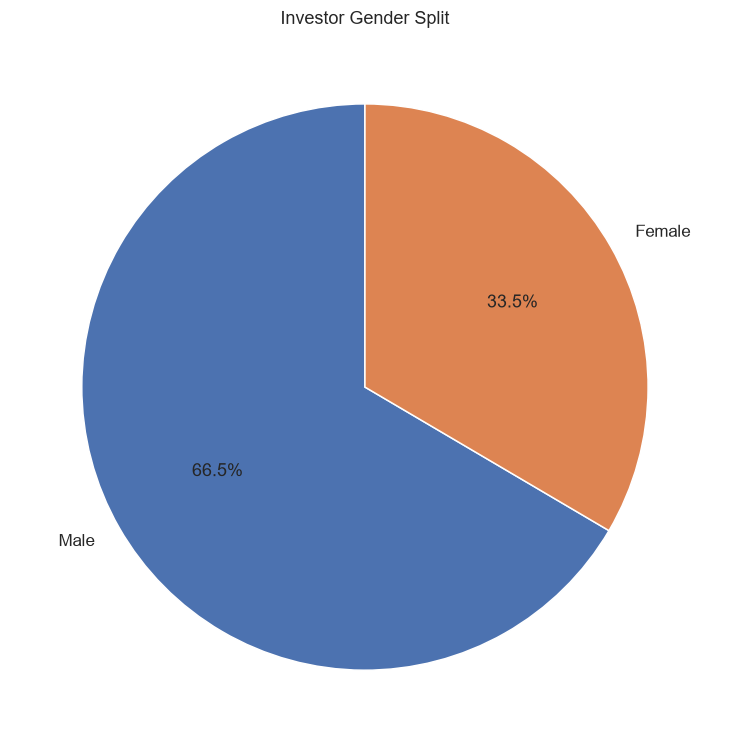

In [11]:
# Chart 5a: Age group distribution pie chart
age_dist = transactions["age_group"].value_counts()

fig5a, ax5a = plt.subplots(figsize=(8, 8))
ax5a.pie(age_dist.values, labels=age_dist.index, autopct="%1.1f%%", startangle=90)
ax5a.set_title("Investor Age Group Distribution")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05a_age_group_distribution.png")
plt.show()

# Chart 5b: SIP amount box plot by age group
sip_only = transactions[transactions["transaction_type"] == "SIP"]

fig5b, ax5b = plt.subplots(figsize=(12, 6))
sns.boxplot(data=sip_only, x="age_group", y="amount_inr", order=sorted(age_dist.index), ax=ax5b)
ax5b.set_title("SIP Amount Distribution by Age Group")
ax5b.set_xlabel("Age Group")
ax5b.set_ylabel("SIP Amount (INR)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05b_sip_amount_by_age.png")
plt.show()

# Chart 5c: Gender split pie chart
gender_dist = transactions["gender"].value_counts()

fig5c, ax5c = plt.subplots(figsize=(7, 7))
ax5c.pie(gender_dist.values, labels=gender_dist.index, autopct="%1.1f%%", startangle=90, colors=["#4C72B0", "#DD8452"])
ax5c.set_title("Investor Gender Split")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05c_gender_split.png")
plt.show()

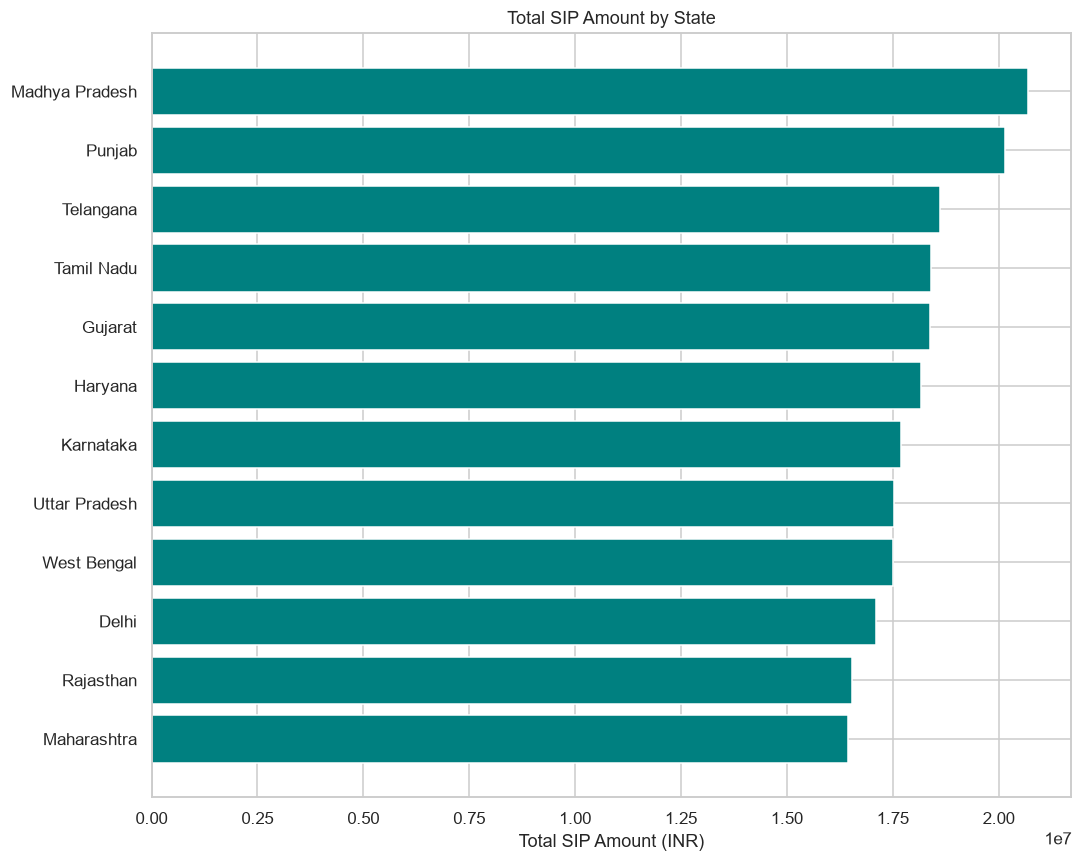

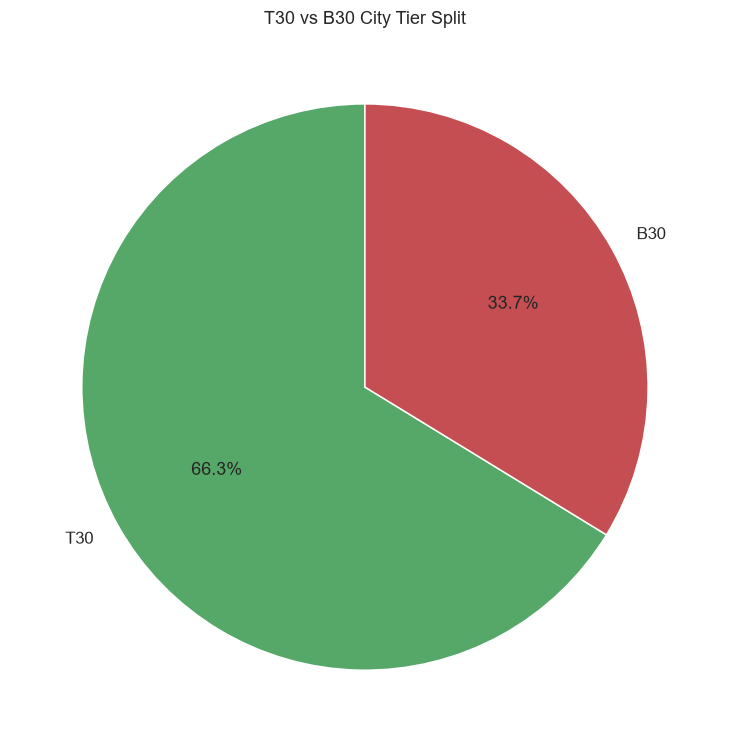

In [13]:
# Chart 6a: SIP amount by state, horizontal bar chart
sip_by_state = sip_only.groupby("state")["amount_inr"].sum().sort_values(ascending=True)

fig6a, ax6a = plt.subplots(figsize=(10, 8))
ax6a.barh(sip_by_state.index, sip_by_state.values, color="teal")
ax6a.set_title("Total SIP Amount by State")
ax6a.set_xlabel("Total SIP Amount (INR)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06a_sip_amount_by_state.png")
plt.show()

# Chart 6b: T30 vs B30 city tier pie chart
tier_dist = transactions["city_tier"].value_counts()

fig6b, ax6b = plt.subplots(figsize=(7, 7))
ax6b.pie(tier_dist.values, labels=tier_dist.index, autopct="%1.1f%%", startangle=90, colors=["#55A868", "#C44E52"])
ax6b.set_title("T30 vs B30 City Tier Split")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06b_city_tier_split.png")
plt.show()

In [14]:
# Chart 7: Folio count growth line chart with milestone markers
folio_sorted = folio_count.sort_values("month")

fig7 = go.Figure()
fig7.add_trace(go.Scatter(
    x=folio_sorted["month"], y=folio_sorted["total_folios_crore"],
    mode="lines+markers", line=dict(color="darkgreen", width=2), name="Total Folios"
))

# Mark start and end milestones
start_row = folio_sorted.iloc[0]
end_row = folio_sorted.iloc[-1]

fig7.add_annotation(x=start_row["month"], y=start_row["total_folios_crore"],
                     text=f"{start_row['total_folios_crore']} Cr", showarrow=True, arrowhead=2, ay=-40)
fig7.add_annotation(x=end_row["month"], y=end_row["total_folios_crore"],
                     text=f"{end_row['total_folios_crore']} Cr", showarrow=True, arrowhead=2, ay=-40)

fig7.update_layout(title="Industry Folio Count Growth (Jan 2022 - Dec 2025)", xaxis_title="Month", yaxis_title="Total Folios (Crore)", height=500)
fig7.write_image(f"{CHARTS_DIR}/07_folio_growth.png", width=1400, height=600)
fig7.show()

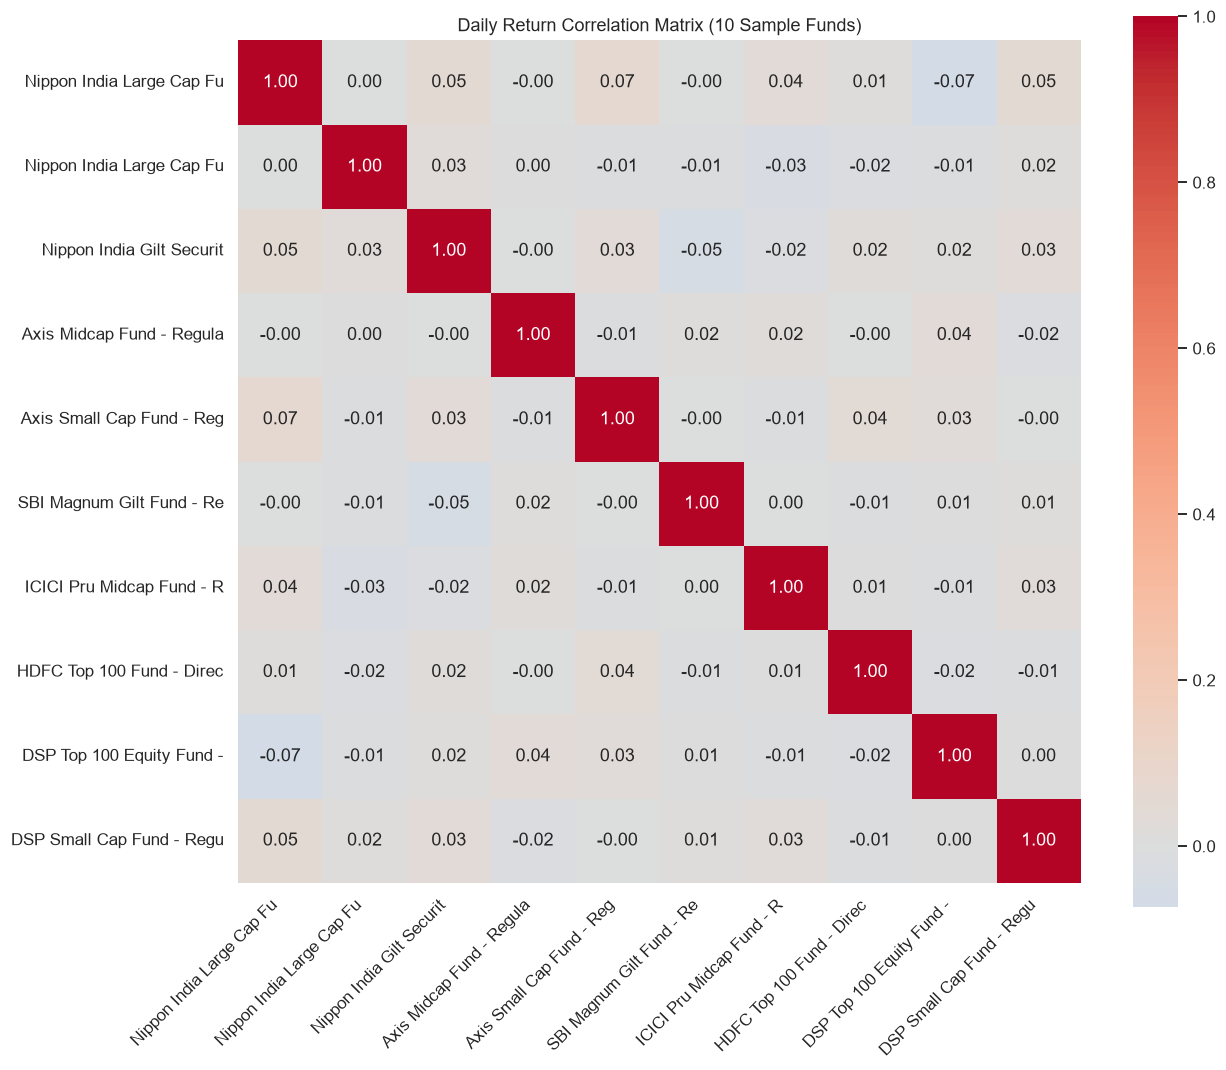

In [16]:
# Chart 8: Correlation matrix of daily returns for 10 selected funds
sample_codes = fund_master["amfi_code"].sample(10, random_state=42).tolist()
nav_sample = nav_history[nav_history["amfi_code"].isin(sample_codes)]
nav_sample_wide = nav_sample.pivot(index="date", columns="amfi_code", values="nav")
nav_sample_wide.columns = [fund_master.set_index("amfi_code").loc[c, "scheme_name"][:25] for c in nav_sample_wide.columns]

returns_sample = nav_sample_wide.pct_change().dropna()
corr_matrix = returns_sample.corr()

fig8, ax8 = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax8)
ax8.set_title("Daily Return Correlation Matrix (10 Sample Funds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/08_return_correlation_matrix.png")
plt.show()

In [17]:
# Chart 9: Aggregate sector weights across all equity fund holdings
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig9 = go.Figure(data=[go.Pie(
    labels=sector_weights.index, values=sector_weights.values, hole=0.4
)])
fig9.update_layout(title="Aggregate Sector Allocation Across Equity Fund Holdings", height=600)
fig9.write_image(f"{CHARTS_DIR}/09_sector_allocation_donut.png", width=900, height=700)
fig9.show()

C:\Users\vinodk\AppData\Local\Temp\ipykernel_4664\732744694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_dist.values, y=payment_dist.index, ax=ax10, palette="viridis")


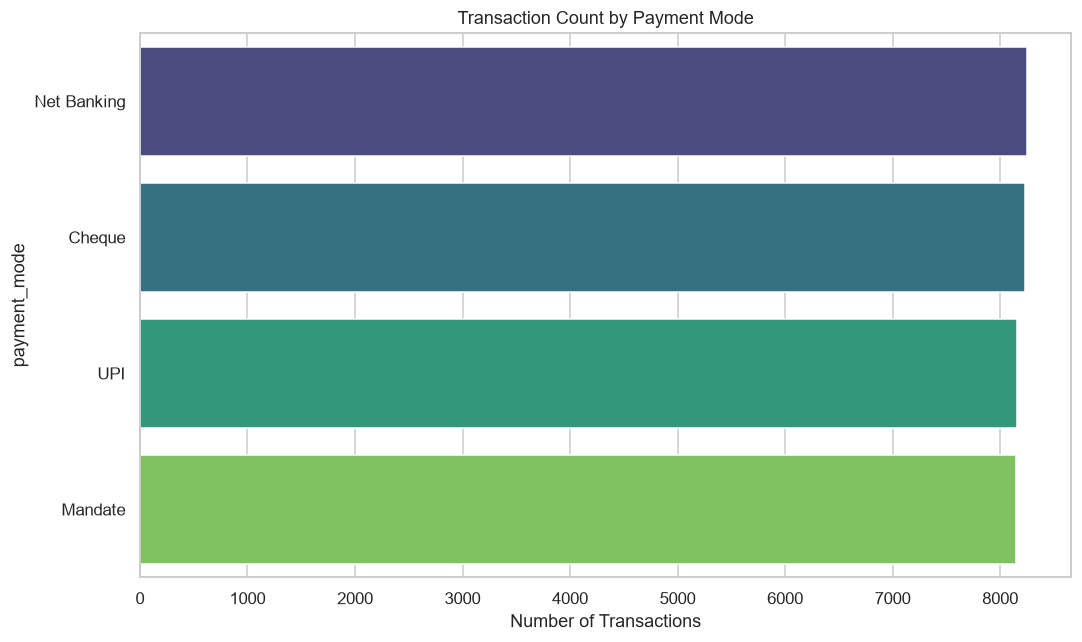

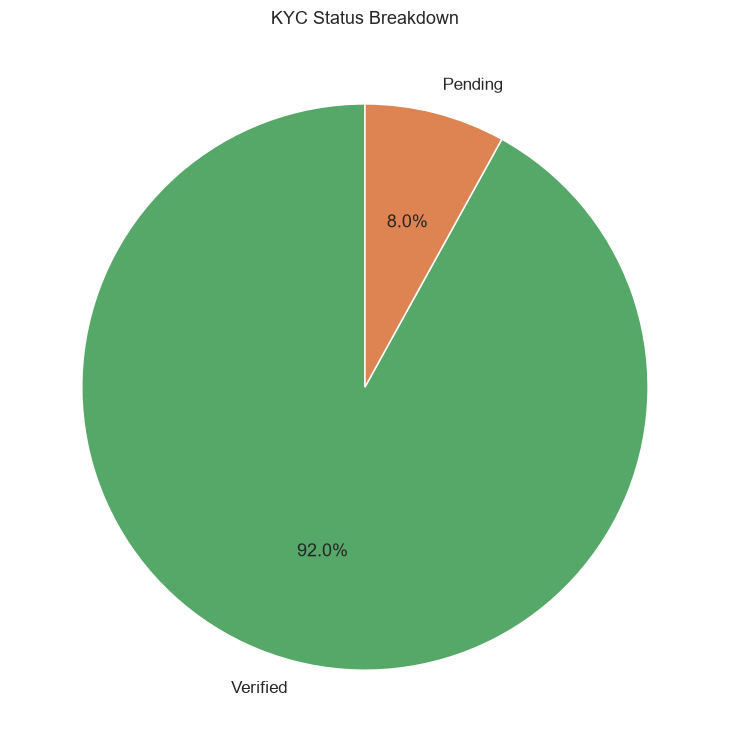

C:\Users\vinodk\AppData\Local\Temp\ipykernel_4664\732744694.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_dist.index, y=rating_dist.values, ax=ax12, palette="rocket")


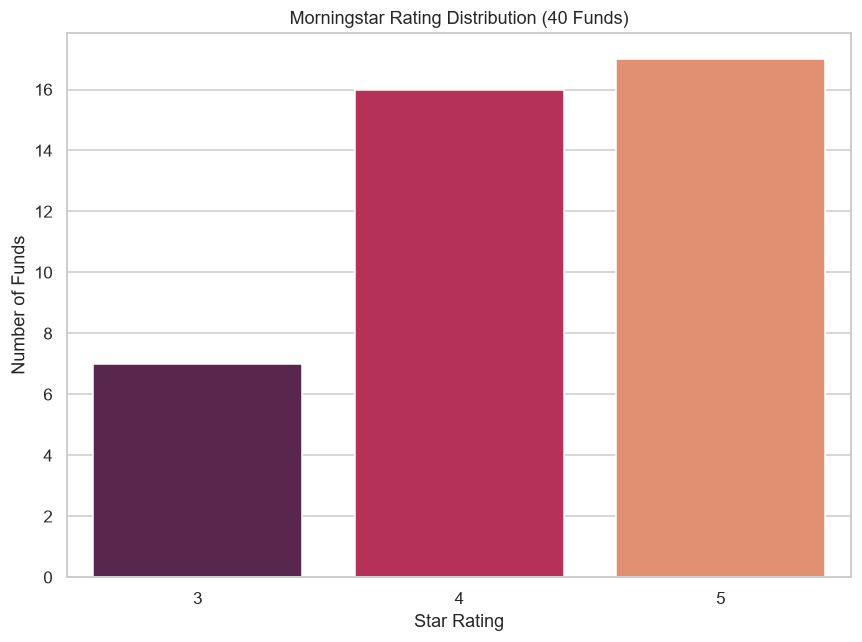

In [18]:
# Bonus Chart 10: Payment mode distribution
payment_dist = transactions["payment_mode"].value_counts()

fig10, ax10 = plt.subplots(figsize=(10, 6))
sns.barplot(x=payment_dist.values, y=payment_dist.index, ax=ax10, palette="viridis")
ax10.set_title("Transaction Count by Payment Mode")
ax10.set_xlabel("Number of Transactions")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/10_payment_mode_distribution.png")
plt.show()

# Bonus Chart 11: KYC status breakdown
kyc_dist = transactions["kyc_status"].value_counts()

fig11, ax11 = plt.subplots(figsize=(7, 7))
ax11.pie(kyc_dist.values, labels=kyc_dist.index, autopct="%1.1f%%", startangle=90, colors=["#55A868", "#DD8452"])
ax11.set_title("KYC Status Breakdown")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/11_kyc_status_breakdown.png")
plt.show()

# Bonus Chart 12: Morningstar rating distribution across the 40-fund universe
rating_dist = fund_master.merge(
    pd.read_csv(f"{DATA_DIR}/07_scheme_performance.csv")[["amfi_code", "morningstar_rating"]],
    on="amfi_code"
)["morningstar_rating"].value_counts().sort_index()

fig12, ax12 = plt.subplots(figsize=(8, 6))
sns.barplot(x=rating_dist.index, y=rating_dist.values, ax=ax12, palette="rocket")
ax12.set_title("Morningstar Rating Distribution (40 Funds)")
ax12.set_xlabel("Star Rating")
ax12.set_ylabel("Number of Funds")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/12_morningstar_rating_distribution.png")
plt.show()

### Key Finding 1: Sustained NAV Growth Across the Universe
Daily NAV trends for all 40 schemes show a broadly upward trajectory from 2022 to 2026, with a visible acceleration during the 2023 bull run and a flattening/pullback period through 2024. *(See Chart 1: NAV Trend)*

### Key Finding 2: AUM Concentration Among Top Fund Houses
AUM growth by fund house shows meaningful variation year-over-year, with certain AMCs consistently commanding a larger share of industry assets. *(See Chart 2: AUM Growth by Fund House)*

### Key Finding 3: SIP Inflows Hit an All-Time High in December 2025
Monthly SIP inflows grew substantially from January 2022 through December 2025, peaking at ₹31,002 Cr — the all-time high in the dataset, reflecting sustained retail investor confidence in systematic investing. *(See Chart 3: SIP Inflow Trend)*

### Key Finding 4: Category Inflows Vary Significantly by Month and Type
The category inflow heatmap reveals that certain fund categories attract disproportionately higher net inflows in specific months, suggesting seasonal or sentiment-driven shifts in investor category preference. *(See Chart 4: Category Inflow Heatmap)*

### Key Finding 5: Younger and Middle-Age Investors Dominate Transaction Volume
The age group distribution shows that the 26-35 and 36-45 brackets account for the largest share of transactions, with SIP amounts varying meaningfully across age groups per the box plot distribution. *(See Chart 5: Investor Demographics)*

### Key Finding 6: Gender Split Shows a Skew in Transaction Participation
The gender breakdown of transactions reveals an imbalance in participation, which may reflect broader patterns in financial market access and engagement. *(See Chart 5c: Gender Split)*

### Key Finding 7: SIP Investment Is Geographically Concentrated
The horizontal bar chart of SIP amount by state shows meaningful variation across India's 12 represented states, with certain states contributing disproportionately to total SIP volume relative to others. *(See Chart 6a: SIP Amount by State)*

### Key Finding 8: T30 Cities Continue to Lead B30 in Transaction Share
The city tier split confirms that Tier-1/Tier-2 (T30) cities still account for a larger share of transactions than smaller (B30) cities, though B30 representation remains substantial — a signal of broadening retail participation beyond metros. *(See Chart 6b: City Tier Split)*

### Key Finding 9: Investor Folios Nearly Doubled Over the Analysis Period
Total industry folios grew from 13.26 Cr in January 2022 to 26.12 Cr in December 2025 — essentially doubling — reflecting significant expansion in the retail investor base over the four-year window. *(See Chart 7: Folio Count Growth)*

### Key Finding 10: Fund Return Correlations Are Generally Low
The correlation matrix of daily returns across 10 sample funds shows generally low pairwise correlation, suggesting the fund universe (or this synthetic dataset) offers meaningful diversification potential between schemes — though this finding aligns with the earlier observation of unexpectedly low benchmark correlation and may warrant the same data validation noted in the Performance Analytics report. *(See Chart 8: Return Correlation Matrix)*